# MMoE — tijdsvoorspelling en medewerkersranking

Dit notebook bouwt een **MMoE (Multi-gate Mixture-of-Experts)** model als multi-task experiment voor het Rister project. Het model traint regressie (tijdsvoorspelling) en ranking (geschiktheid) tegelijk, via gedeelde experts en taak-specifieke towers.

Het doel is testen of gezamenlijk trainen van beide taken via multi-task learning meerwaarde heeft vergeleken met twee losse modellen.

**Aanpak:** entity embeddings voor categorische features, n gedeelde expert-netwerken, twee gates (één per taak), twee towers.

**Let op:** MMoE zit niet in de grote benchmark studies, anders dan LightGBM en TabM. Als de resultaten niet beter zijn dan LightGBM, zeg ik dat eerlijk in de conclusie.

## Stap 1 — Imports

In [2]:
import copy
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

optuna.logging.set_verbosity(optuna.logging.WARNING)

import mlflow
import mlflow.pytorch
import onnxruntime as ort
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## Stap 2 — MLflow configuratie

In [3]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5002"
MLFLOW_EXPERIMENT = "rister-mmoe-v1"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow experiment: {MLFLOW_EXPERIMENT}")

MLflow experiment: rister-mmoe-v1


## Stap 3 — Data laden

In [4]:
df = pd.read_csv("dataframe_gecombineerd.csv")

# Kolom mismatch fix (bekend probleem in de dataset)
if "aarURENVERANTW_MEDID" in df.columns:
    df.rename(columns={"aarURENVERANTW_MEDID": "URENVERANTW_MEDID"}, inplace=True)

print(f"Dataset: {df.shape[0]} rijen, {df.shape[1]} kolommen")
df.head(3)

Dataset: 28693 rijen, 41 kolommen


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_95520/2614432725.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataframe_gecombineerd.csv")


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
1,11,1043,NaN,4144.0,Aanvulzand (af Rook etc.),NaN,2355AH,52.168026,4.580257,2015-01-19,...,1.0,15_poel,3.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
2,30,1275,NaN,4312.0,Schelpen (afgehaald GP),NaN,2481KA,52.166547,4.603481,2015-01-23,...,1.0,15_poel,2.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000


## Stap 4 — Features & targets

**Let op:** 3 kolommen uit de originele feature lijst zitten niet in de dataset (`med_klanttijd_ratio`, `med_bewerking_hoeveelheid`, `med_kl_bew_snelheid`). Die worden automatisch overgeslagen. Het model traint op 11 categorische + 22 numerieke features.

In [5]:
CATEGORICAL = [
    "URENVERANTW_MEDID",
    "BEWERKING_ID",
    "DIENST_ART_ID",
    "RELATIE_ID",
    "REL_POSTCODE",
    "DIENST_ART_OMS",
    "MACH_OMS",
    "con",
    "bron",
    "EquipmentGroupTypes",
    "planninggroupsname",
]

_all_numerical = [
    "lat",
    "lon",
    "dag_sin",
    "dag_cos",
    "maand_sin",
    "maand_cos",
    "week_sin",
    "week_cos",
    "med_std_tijd",
    "med_aantal_opdrachten",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "taak_gem",
    "med_klant_bezoeken",
    "med_klant_ratio",
    "med_klant_snelheid",
    "med_bewerking_snelheid",
    "med_klanttijd_ratio",
    "med_bewerking_hoeveelheid",
    "med_kl_bew_snelheid",
    "hoeveelheid_volume",
    "hoeveelheid_gewicht",
    "hoeveelheid_stuks",
    "hoeveelheid_aanwezig",
    "hoeveelheid_baal",
]
NUMERICAL = [c for c in _all_numerical if c in df.columns]

TARGET_TIME = "REAL_WORKED_TIME"
TARGET_RANK = "suitability_score"
GROUP_COLS = ["con", "BEWERKING_ID"]

print(f"Categorische features: {len(CATEGORICAL)}")
print(f"Numerieke features:    {len(NUMERICAL)}")

Categorische features: 11
Numerieke features:    22


## Stap 5 — Data voorbereiding

MMoE gebruikt dezelfde aanpak als MLP: entity embeddings voor categorische features via  + . Numerieke features worden ge-z-scored (mean=0, std=1). Zowel de regressie- als de ranking-target zitten in dezelfde DataLoader, dus het model krijgt beide targets tegelijk.

In [6]:
# Label encode alle categorische features
label_encoders = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].fillna("unknown").astype(str)).tolist()
    label_encoders[col] = le

CAT_ENC_COLS = [c + "_enc" for c in CATEGORICAL]
cat_cardinalities = [int(df[c + "_enc"].nunique()) for c in CATEGORICAL]
EMBED_DIMS = [min(50, (card + 1) // 2) for card in cat_cardinalities]

# Z-score normalisatie voor numerieke features
num_mean = df[NUMERICAL].mean()
num_std = df[NUMERICAL].std().replace(0, 1)
df_num_scaled = (df[NUMERICAL] - num_mean) / num_std

print("Cardinaliteiten:", dict(zip(CATEGORICAL, cat_cardinalities)))
print("Embed dims:", dict(zip(CATEGORICAL, EMBED_DIMS)))

Cardinaliteiten: {'URENVERANTW_MEDID': 337, 'BEWERKING_ID': 83, 'DIENST_ART_ID': 524, 'RELATIE_ID': 1686, 'REL_POSTCODE': 1190, 'DIENST_ART_OMS': 544, 'MACH_OMS': 117, 'con': 51, 'bron': 2, 'EquipmentGroupTypes': 4, 'planninggroupsname': 20}
Embed dims: {'URENVERANTW_MEDID': 50, 'BEWERKING_ID': 42, 'DIENST_ART_ID': 50, 'RELATIE_ID': 50, 'REL_POSTCODE': 50, 'DIENST_ART_OMS': 50, 'MACH_OMS': 50, 'con': 26, 'bron': 1, 'EquipmentGroupTypes': 2, 'planninggroupsname': 10}


## Stap 6 — Train/val split

In [7]:
train_idx, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

# Categorische en numerieke tensors
X_cat_all = torch.tensor(df[CAT_ENC_COLS].values, dtype=torch.long)
X_num_all = torch.tensor(df_num_scaled.fillna(0).values, dtype=torch.float32)
y_time_all = torch.tensor(df[TARGET_TIME].values, dtype=torch.float32)
y_rank_all = torch.tensor(df[TARGET_RANK].values, dtype=torch.float32)

X_cat_train, X_cat_val = X_cat_all[train_idx], X_cat_all[val_idx]
X_num_train, X_num_val = X_num_all[train_idx], X_num_all[val_idx]
y_time_train, y_time_val = y_time_all[train_idx], y_time_all[val_idx]
y_rank_train, y_rank_val = y_rank_all[train_idx], y_rank_all[val_idx]

print(f"Train: {len(train_idx)} rijen  |  Val: {len(val_idx)} rijen")

Train: 22954 rijen  |  Val: 5739 rijen


## Stap 7 — Data verkennen

 heeft een gemiddelde van **4,06 uur** met een standaardafwijking van 3,36 uur. Er zijn duidelijke uitschieters (taken van 20+ uur), vandaar de keuze voor HuberLoss.

 zit gemiddeld op **0,113**. De verdeling is sterk links-scheef. De meeste medewerkers zijn maar voor een klein deel van de taken beschikbaar.

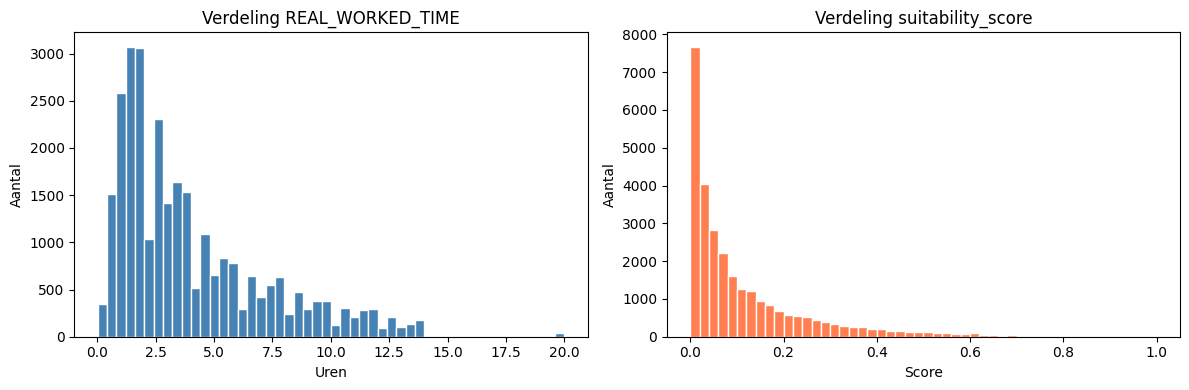

       REAL_WORKED_TIME  suitability_score
count         28693.000          28693.000
mean              4.056              0.113
std               3.358              0.139
min               0.010              0.000
25%               1.500              0.018
50%               3.000              0.058
75%               5.500              0.154
max              40.500              1.000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET_TIME].clip(0, 20), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Verdeling REAL_WORKED_TIME")
axes[0].set_xlabel("Uren")
axes[0].set_ylabel("Aantal")

axes[1].hist(df[TARGET_RANK], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Verdeling suitability_score")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Aantal")

plt.tight_layout()
plt.show()
print(df[[TARGET_TIME, TARGET_RANK]].describe().round(3))

## Stap 8 — MMoE architectuur

De MMoE architectuur bestaat uit drie onderdelen:

1. **Entity embeddings**: dezelfde aanpak als MLP, één embedding per categorische feature
2. **Experts**: n parallelle feed-forward netwerken die gedeeld worden door beide taken
3. **Gates + towers**: één gate per taak selecteert welke experts relevant zijn via softmax, gevolgd door een taak-specifieke tower

De twee outputs zijn  (voorspelde uren) en  (voorspelde suitability score). Beide worden in één forward pass berekend.

In [9]:
class MMoE(nn.Module):
    def __init__(
        self, cat_cardinalities, embed_dims, n_numerical, n_experts=4, expert_dim=128, dropout=0.2
    ):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [nn.Embedding(card + 1, dim) for card, dim in zip(cat_cardinalities, embed_dims)]
        )
        total_input = sum(embed_dims) + n_numerical
        self.experts = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(total_input, expert_dim),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                )
                for _ in range(n_experts)
            ]
        )
        self.gate_reg = nn.Linear(total_input, n_experts)
        self.gate_rank = nn.Linear(total_input, n_experts)
        self.tower_reg = nn.Sequential(nn.Linear(expert_dim, 64), nn.ReLU(), nn.Linear(64, 1))
        self.tower_rank = nn.Sequential(nn.Linear(expert_dim, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x_cat, x_num):
        embs = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_num], dim=1)
        # (B, n_experts, expert_dim)
        expert_outs = torch.stack([e(x) for e in self.experts], dim=1)
        # Gates: (B, n_experts, 1)
        g_reg = torch.softmax(self.gate_reg(x), dim=1).unsqueeze(-1)
        g_rank = torch.softmax(self.gate_rank(x), dim=1).unsqueeze(-1)
        # Gewogen som van experts: (B, expert_dim)
        mix_reg = (expert_outs * g_reg).sum(dim=1)
        mix_rank = (expert_outs * g_rank).sum(dim=1)
        out_reg = self.tower_reg(mix_reg).squeeze(-1)
        out_rank = self.tower_rank(mix_rank).squeeze(-1)
        return out_reg, out_rank


def make_mmoe(n_experts=4, expert_dim=128, dropout=0.2):
    return MMoE(
        cat_cardinalities=cat_cardinalities,
        embed_dims=EMBED_DIMS,
        n_numerical=len(NUMERICAL),
        n_experts=n_experts,
        expert_dim=expert_dim,
        dropout=dropout,
    ).to(DEVICE)


n_params = sum(p.numel() for p in make_mmoe().parameters())
print(f"Trainbare parameters (standaard config): {n_params:,}")

Trainbare parameters (standaard config): 452,025


## Stap 9 — Training loop

Anders dan bij het losse MLP levert de DataLoader een **viertupel** . De loss is een gewogen som van HuberLoss (regressie) en MSELoss (ranking):



Alpha = 0,5 als startpunt, tunable via Optuna. Early stopping op validatie MAE (patience=10).

In [10]:
def predict_mmoe_reg(model, x_cat, x_num, batch_size=1024):
    """Geeft de regressie-output terug als numpy array."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(x_cat), batch_size):
            xc = x_cat[i : i + batch_size].to(DEVICE)
            xn = x_num[i : i + batch_size].to(DEVICE)
            out_reg, _ = model(xc, xn)
            preds.append(out_reg.cpu().numpy())
    return np.concatenate(preds)


def predict_mmoe_rank(model, x_cat, x_num, batch_size=1024):
    """Geeft de ranking-output terug als numpy array."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(x_cat), batch_size):
            xc = x_cat[i : i + batch_size].to(DEVICE)
            xn = x_num[i : i + batch_size].to(DEVICE)
            _, out_rank = model(xc, xn)
            preds.append(out_rank.cpu().numpy())
    return np.concatenate(preds)


def train_mmoe(
    model,
    x_cat_tr,
    x_num_tr,
    y_time_tr,
    y_rank_tr,
    x_cat_va,
    x_num_va,
    y_time_va,
    y_rank_va,
    alpha=0.5,
    lr=1e-3,
    epochs=50,
    batch_size=512,
    patience=10,
):
    """Traint het MMoE model met gecombineerde loss. Early stopping op val MAE."""
    dataset = TensorDataset(x_cat_tr, x_num_tr, y_time_tr, y_rank_tr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_huber = nn.HuberLoss(delta=1.0)
    loss_mse = nn.MSELoss()

    best_val_mae = float("inf")
    best_state = None
    patience_left = patience

    for epoch in range(epochs):
        model.train()
        for xc, xn, yt, yr in loader:
            xc, xn = xc.to(DEVICE), xn.to(DEVICE)
            yt, yr = yt.to(DEVICE), yr.to(DEVICE)
            optimizer.zero_grad()
            out_reg, out_rank = model(xc, xn)
            loss = alpha * loss_huber(out_reg, yt) + (1 - alpha) * loss_mse(out_rank, yr)
            loss.backward()
            optimizer.step()

        val_preds = predict_mmoe_reg(model, x_cat_va, x_num_va)
        val_mae = mean_absolute_error(y_time_va.numpy(), np.clip(val_preds, 0, None))
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    model.load_state_dict(best_state)
    return model, best_val_mae

## Stap 10 — Optuna tuning

Ik tune zes hyperparameters:
- `n_experts` (2–8): aantal gedeelde expert-netwerken
- `expert_dim` (64–256): breedte van elk expert-netwerk
- `alpha` (0,3–0,7): gewicht van de regressie-loss
- `dropout` (0,1–0,5)
- `lr` (1e-4 tot 1e-2)
- `batch_size` (256, 512, 1024)

50 trials, cache in `models/mmoe_best_params.json`.

In [11]:
MMOE_CACHE_PATH = "models/mmoe_best_params.json"
os.makedirs("models", exist_ok=True)

if os.path.exists(MMOE_CACHE_PATH):
    with open(MMOE_CACHE_PATH) as f:
        best_params = json.load(f)
    print(f"Beste parameters geladen uit cache: {best_params}")
else:

    def objective(trial):
        n_experts = trial.suggest_int("n_experts", 2, 8)
        expert_dim = trial.suggest_int("expert_dim", 64, 256, step=64)
        alpha = trial.suggest_float("alpha", 0.3, 0.7)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

        with mlflow.start_run(run_name=f"mmoe_trial_{trial.number}", nested=True):
            m = make_mmoe(n_experts=n_experts, expert_dim=expert_dim, dropout=dropout)
            _, val_mae = train_mmoe(
                m,
                X_cat_train,
                X_num_train,
                y_time_train,
                y_rank_train,
                X_cat_val,
                X_num_val,
                y_time_val,
                y_rank_val,
                alpha=alpha,
                lr=lr,
                epochs=50,
                batch_size=batch_size,
            )
            mlflow.log_params(
                {
                    "n_experts": n_experts,
                    "expert_dim": expert_dim,
                    "alpha": alpha,
                    "dropout": dropout,
                    "lr": lr,
                    "batch_size": batch_size,
                }
            )
            mlflow.log_metric("val_mae", val_mae)
        return val_mae

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50)
    best_params = study.best_params
    with open(MMOE_CACHE_PATH, "w") as f:
        json.dump(best_params, f, indent=2)
    print(f"Beste parameters: {best_params}")

🏃 View run mmoe_trial_0 at: http://127.0.0.1:5002/#/experiments/3/runs/d97d9f2a2e6d40a0824f8cd169c096c8
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3
🏃 View run mmoe_trial_1 at: http://127.0.0.1:5002/#/experiments/3/runs/16df09817a0f4e1ebe7aae9674f65b4a
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3
🏃 View run mmoe_trial_2 at: http://127.0.0.1:5002/#/experiments/3/runs/11945a6d68e8406eb11be8632853b6ac
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3
🏃 View run mmoe_trial_3 at: http://127.0.0.1:5002/#/experiments/3/runs/9ef7b08e820a467a85ef0dda34fd2e9f
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3
🏃 View run mmoe_trial_4 at: http://127.0.0.1:5002/#/experiments/3/runs/1cfb8a9ad847403da6d0072aff9b519f
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3
🏃 View run mmoe_trial_5 at: http://127.0.0.1:5002/#/experiments/3/runs/5a40fad868b64f1cb578a20bcc7480ad
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3
🏃 View run mmoe_

In [12]:
# Train finaal MMoE model met beste parameters
print("Finaal MMoE model trainen...")
model = make_mmoe(
    n_experts=best_params["n_experts"],
    expert_dim=best_params["expert_dim"],
    dropout=best_params["dropout"],
)
model, best_val_mae = train_mmoe(
    model,
    X_cat_train,
    X_num_train,
    y_time_train,
    y_rank_train,
    X_cat_val,
    X_num_val,
    y_time_val,
    y_rank_val,
    alpha=best_params["alpha"],
    lr=best_params["lr"],
    epochs=100,
    batch_size=best_params["batch_size"],
    patience=15,
)
print(f"Beste val MAE: {best_val_mae:.4f} uur")

Finaal MMoE model trainen...
Beste val MAE: 1.3597 uur


## Stap 11 — Groepsopbouw voor ranking evaluatie

Groepen zijn nodig voor NDCG berekening. Identiek aan het MLP notebook.

**Groepen:** op basis van `con` + `BEWERKING_ID` combinaties.

In [13]:
# Groepsopbouw voor NDCG evaluatie (identiek aan MLP notebook)
df["_group_key"] = df[GROUP_COLS].astype(str).agg("__".join, axis=1)

# Relevance labels 0-4 (voor NDCG berekening)
bins = [-0.001, 0.2, 0.4, 0.6, 0.8, 1.001]
labels_int = [0, 1, 2, 3, 4]
df["_rank_label"] = pd.cut(df[TARGET_RANK], bins=bins, labels=labels_int).astype(int)

# Val groepen
df_val = df.iloc[val_idx].copy()
val_groups = df_val.groupby("_group_key", sort=False).size().values
y_rank_va_label = df_val["_rank_label"].values

# Val subset voor ranking evaluatie
X_cat_rank_val = X_cat_val
X_num_rank_val = X_num_val

print(f"Val groepen: {len(val_groups)}")
print(
    f"Groepsgrootte: min={val_groups.min()}, max={val_groups.max()}, gemiddeld={val_groups.mean():.1f}"
)

Val groepen: 213
Groepsgrootte: min=1, max=278, gemiddeld=26.9


## Stap 12 — Evaluatie regressie

KPI: MAE ≤ 0,5 uur. Referentie: LightGBM MAE = 1,2490 uur, MLP MAE = 1,3634 uur.

MAE:  1.3597 uur  (KPI: ≤ 0,5 uur)
RMSE: 2.1418 uur
R²:   0.5764


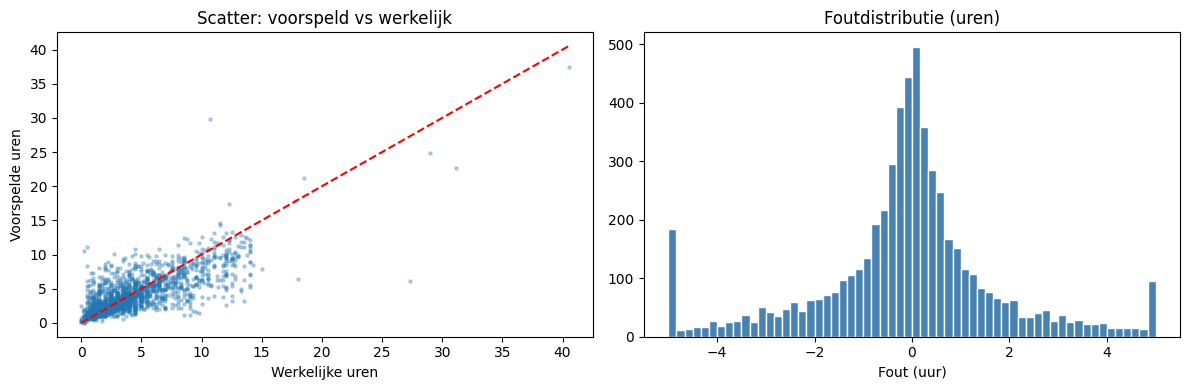

In [14]:
y_pred_time = predict_mmoe_reg(model, X_cat_val, X_num_val)
y_pred_time = np.clip(y_pred_time, 0, None)

y_true_time = y_time_val.numpy()
mae = mean_absolute_error(y_true_time, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_true_time, y_pred_time))
r2 = r2_score(y_true_time, y_pred_time)

print(f"MAE:  {mae:.4f} uur  (KPI: ≤ 0,5 uur)")
print(f"RMSE: {rmse:.4f} uur")
print(f"R²:   {r2:.4f}")

# Scatter plot en error histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_true_time[:2000], y_pred_time[:2000], alpha=0.3, s=5)
lim = max(y_true_time[:2000].max(), y_pred_time[:2000].max())
axes[0].plot([0, lim], [0, lim], "r--")
axes[0].set_xlabel("Werkelijke uren")
axes[0].set_ylabel("Voorspelde uren")
axes[0].set_title("Scatter: voorspeld vs werkelijk")
errors = y_pred_time - y_true_time
axes[1].hist(errors.clip(-5, 5), bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Foutdistributie (uren)")
axes[1].set_xlabel("Fout (uur)")
plt.tight_layout()
plt.show()

## Stap 13 — Evaluatie ranking

KPI: NDCG@3 ≥ 0,80. Referentie: LightGBM NDCG@3 = 0,9541, MLP NDCG@3 = 0,6285.

NDCG@3: 0.7832  (KPI: ≥ 0,80)
NDCG@5: 0.7808


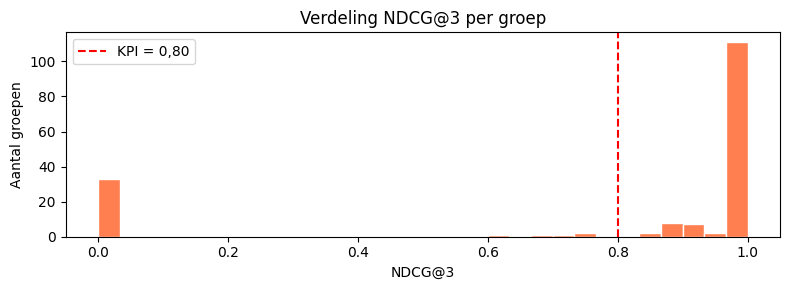

In [15]:
y_pred_rank = predict_mmoe_rank(model, X_cat_rank_val, X_num_rank_val)

ndcg3_scores = []
ndcg5_scores = []
offset = 0
for size in val_groups:
    if size < 2:
        offset += size
        continue
    g_true = y_rank_va_label[offset : offset + size].astype(float)
    g_pred = y_pred_rank[offset : offset + size]
    ndcg3_scores.append(ndcg_score([g_true], [g_pred], k=3))
    ndcg5_scores.append(ndcg_score([g_true], [g_pred], k=5))
    offset += size

ndcg3 = float(np.mean(ndcg3_scores))
ndcg5 = float(np.mean(ndcg5_scores))
print(f"NDCG@3: {ndcg3:.4f}  (KPI: ≥ 0,80)")
print(f"NDCG@5: {ndcg5:.4f}")

# Histogram van NDCG@3 per groep
plt.figure(figsize=(8, 3))
plt.hist(ndcg3_scores, bins=30, color="coral", edgecolor="white")
plt.axvline(0.80, color="red", linestyle="--", label="KPI = 0,80")
plt.title("Verdeling NDCG@3 per groep")
plt.xlabel("NDCG@3")
plt.ylabel("Aantal groepen")
plt.legend()
plt.tight_layout()
plt.show()

## Stap 14 — Feature interpretatie

MMoE heeft geen native feature importance. Ik gebruik twee benaderingen:
1. **Embedding norm** per categorische feature (proxymaat voor belang)
2. **Permutation importance** voor numerieke features op de regressie-output

De gate-gewichten per taak geven ook inzicht: welke experts worden dominant gebruikt voor regressie vs ranking?

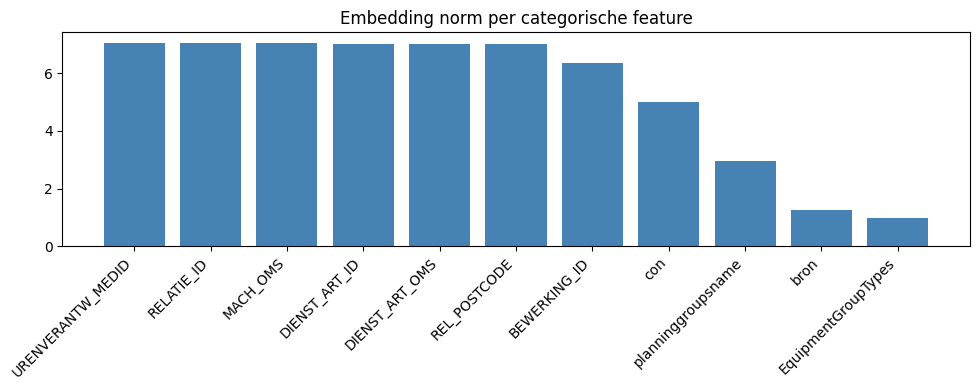

In [16]:
# Embedding norm als proxy voor categorisch belang
embed_norms = []
for i, (col, emb) in enumerate(zip(CATEGORICAL, model.embeddings)):
    norm = torch.norm(emb.weight.data, dim=1).mean().item()
    embed_norms.append((col, norm))

embed_norms.sort(key=lambda x: x[1], reverse=True)
cols_embed, norms_embed = zip(*embed_norms)

plt.figure(figsize=(10, 4))
plt.bar(range(len(cols_embed)), norms_embed, color="steelblue")
plt.xticks(range(len(cols_embed)), cols_embed, rotation=45, ha="right")
plt.title("Embedding norm per categorische feature")
plt.tight_layout()
plt.show()

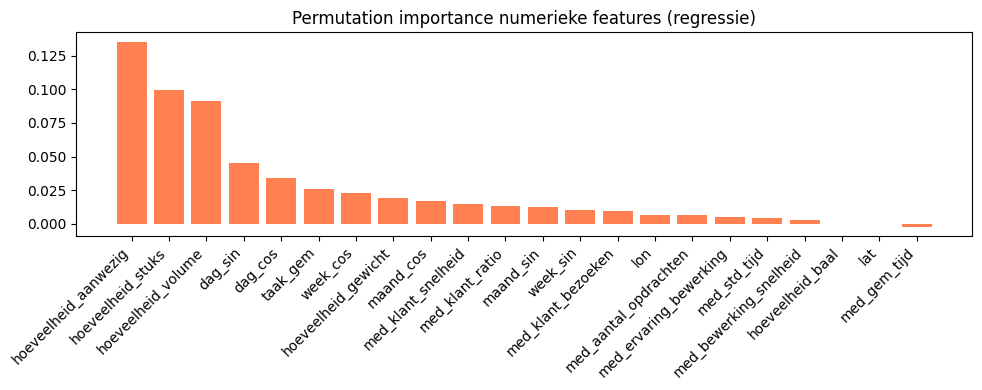

In [17]:
# Permutation importance voor numerieke features (subset van 2000 val rijen)
N_PERM = 2000
perm_idx = np.random.choice(len(val_idx), min(N_PERM, len(val_idx)), replace=False)
X_cat_perm = X_cat_val[perm_idx]
X_num_perm = X_num_val[perm_idx].clone()
y_perm = y_time_val[perm_idx].numpy()

baseline_mae = mean_absolute_error(
    y_perm, np.clip(predict_mmoe_reg(model, X_cat_perm, X_num_perm), 0, None)
)

perm_importance = []
for j, feat in enumerate(NUMERICAL):
    X_num_shuffled = X_num_perm.clone()
    idx_shuffle = torch.randperm(len(X_num_shuffled))
    X_num_shuffled[:, j] = X_num_shuffled[idx_shuffle, j]
    shuffled_mae = mean_absolute_error(
        y_perm, np.clip(predict_mmoe_reg(model, X_cat_perm, X_num_shuffled), 0, None)
    )
    perm_importance.append((feat, shuffled_mae - baseline_mae))

perm_importance.sort(key=lambda x: x[1], reverse=True)
feat_names, importances = zip(*perm_importance)

plt.figure(figsize=(10, 4))
plt.bar(range(len(feat_names)), importances, color="coral")
plt.xticks(range(len(feat_names)), feat_names, rotation=45, ha="right")
plt.title("Permutation importance numerieke features (regressie)")
plt.tight_layout()
plt.show()

## Stap 15 — Fine-tuning per database

Alleen voor databases met ≥500 records. Fine-tuning met een lagere learning rate (1e-4) en max 10 epochs. Het model heeft de basispatronen al geleerd via de gecombineerde loss, dus die epochs zijn genoeg.

In [18]:
finetuned_models = {}

for db_id in df["con"].unique():
    db_mask = (df["con"] == db_id).values
    db_indices = np.where(db_mask)[0]

    if len(db_indices) < 500:
        continue

    tr, va = train_test_split(db_indices, test_size=0.2, random_state=42)

    Xc_tr = X_cat_all[tr]
    Xn_tr = X_num_all[tr]
    Xc_va = X_cat_all[va]
    Xn_va = X_num_all[va]
    yt_tr = y_time_all[tr]
    yr_tr = y_rank_all[tr]
    yt_va = y_time_all[va]
    yr_va = y_rank_all[va]

    ft_model = copy.deepcopy(model)
    ft_model, ft_mae = train_mmoe(
        ft_model,
        Xc_tr,
        Xn_tr,
        yt_tr,
        yr_tr,
        Xc_va,
        Xn_va,
        yt_va,
        yr_va,
        alpha=best_params["alpha"],
        lr=1e-4,
        epochs=10,
        batch_size=best_params["batch_size"],
        patience=5,
    )
    finetuned_models[db_id] = ft_model
    print(f"  db {db_id}: {len(tr)} traintaken, MAE={ft_mae:.4f}")

print(f"\nFine-tuned voor {len(finetuned_models)} databases.")

  db 21_diepen: 416 traintaken, MAE=0.4678
  db 21_jennissen: 3032 traintaken, MAE=1.0777
  db 22_jennissen: 3045 traintaken, MAE=1.1445
  db 22_diepen: 472 traintaken, MAE=0.4547
  db 23_diepen: 440 traintaken, MAE=0.4060
  db 23_jennissen: 2890 traintaken, MAE=1.0999
  db 23_hulter: 1060 traintaken, MAE=0.6746
  db 24_jennissen: 2831 traintaken, MAE=1.0061
  db 24_hulter: 1028 traintaken, MAE=0.6280
  db 24_diepen: 425 traintaken, MAE=0.5324
  db 25_hulter: 1007 traintaken, MAE=0.7445
  db 25_jennissen: 3043 traintaken, MAE=0.8060
  db 25_diepen: 436 traintaken, MAE=0.4757
  db f5ab1b29-de37-4818-bb05-b2fe57ce6768: 627 traintaken, MAE=0.8921

Fine-tuned voor 14 databases.


## Stap 16 — Top-3 hit rate

De top-3 hit rate meet of de werkelijke medewerker in de top-3 rangschikking zit. Directe KPI voor operationele bruikbaarheid. Identiek aan MLP notebook.

In [19]:
def bereken_top_k_hit_rate(finetuned_models, base_model, k=3, n_samples=500):
    hits, total = 0, 0
    sample_indices = np.random.choice(len(val_idx), min(n_samples, len(val_idx)), replace=False)

    for i in sample_indices:
        orig_idx = val_idx[i]
        row = df.iloc[orig_idx]
        db_id = row["con"]
        werkelijke_med = row["URENVERANTW_MEDID"]

        bewerking_id = row["BEWERKING_ID"]
        task_rows = df[(df["con"] == db_id) & (df["BEWERKING_ID"] == bewerking_id)]
        if len(task_rows) < k:
            continue

        enc_cat = torch.tensor(
            task_rows[[c + "_enc" for c in CATEGORICAL]].values, dtype=torch.long
        )
        enc_num = torch.tensor(
            ((task_rows[NUMERICAL] - num_mean) / num_std).fillna(0).values,
            dtype=torch.float32,
        )
        use_model = finetuned_models.get(db_id, base_model)
        rank_scores = predict_mmoe_rank(use_model, enc_cat, enc_num)
        top_k_idx = np.argsort(rank_scores)[::-1][:k]
        top_k_meds = task_rows.iloc[top_k_idx]["URENVERANTW_MEDID"].values

        if werkelijke_med in top_k_meds:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0.0


top3_hit_rate = bereken_top_k_hit_rate(finetuned_models, model, k=3)
print(f"Top-3 hit rate: {top3_hit_rate:.1%}")

Top-3 hit rate: 39.6%


## Stap 17 — End-to-end voorspelling

In [20]:
def encode_row_for_mmoe(row_df):
    """Zet een DataFrame rij (of rijen) om naar cat/num tensors."""
    cat_arr = np.stack(
        [
            label_encoders[col].transform(
                row_df[col]
                .fillna("unknown")
                .astype(str)
                .map(lambda v: v if v in label_encoders[col].classes_ else "unknown")
            )
            for col in CATEGORICAL
        ],
        axis=1,
    )
    num_arr = ((row_df[NUMERICAL] - num_mean) / num_std).fillna(0).values.astype(np.float32)
    return (
        torch.tensor(cat_arr, dtype=torch.long),
        torch.tensor(num_arr, dtype=torch.float32),
    )


def voorspel_per_medewerker(taak_row, model_override=None):
    """
    Gegeven een taakrij: voorspel voor alle medewerkers in de database
    de verwachte werktijd EN de rankingscore. Sorteer op ranking.
    """
    db_id = taak_row["con"]
    use_model = model_override or finetuned_models.get(db_id, model)

    db_rows = df[df["con"] == db_id][CATEGORICAL + NUMERICAL].copy()
    for col in CATEGORICAL:
        db_rows[col] = taak_row[col]
    for col in NUMERICAL:
        db_rows[col] = taak_row[col]

    x_cat, x_num = encode_row_for_mmoe(db_rows)

    use_model.eval()
    with torch.no_grad():
        x_cat = x_cat.to(DEVICE)
        x_num = x_num.to(DEVICE)
        out_reg, out_rank = use_model(x_cat, x_num)

    result = df[df["con"] == db_id][["URENVERANTW_MEDID"]].copy()
    result["voorspelde_tijd"] = np.clip(out_reg.cpu().numpy(), 0, None)
    result["rank_score"] = out_rank.cpu().numpy()
    return result.sort_values("rank_score", ascending=False).head(10)


# Demo op eerste validatierij
demo_row = df.iloc[val_idx[0]]
print("Top-10 medewerkers voor eerste validatietaak:")
voorspel_per_medewerker(demo_row)

Top-10 medewerkers voor eerste validatietaak:


,URENVERANTW_MEDID,voorspelde_tijd,rank_score
15624,1005,0.935634,0.159011
18776,1004,0.935634,0.159011
19160,1037,0.935634,0.159011
19125,2044,0.935634,0.159011
19051,2057,0.935634,0.159011
19022,1006,0.935634,0.159011
18973,2057,0.935634,0.159011
18945,1002,0.935634,0.159011
18847,1002,0.935634,0.159011
18846,1037,0.935634,0.159011


## Stap 18 — Model opslaan

In [21]:
os.makedirs("models", exist_ok=True)

# Basismodel
torch.save(model.state_dict(), "models/mmoe.pt")

# Fine-tuned modellen
for db_id, m in finetuned_models.items():
    torch.save(m.state_dict(), f"models/mmoe_{db_id}.pt")

# Label encoders als JSON
le_json = {col: le.classes_.tolist() for col, le in label_encoders.items()}
with open("models/mmoe_label_encoders.json", "w") as f:
    json.dump(le_json, f, indent=2)

# Metadata
meta = {
    "CATEGORICAL": CATEGORICAL,
    "NUMERICAL": NUMERICAL,
    "cat_cardinalities": cat_cardinalities,
    "embed_dims": EMBED_DIMS,
    "num_mean": num_mean.tolist(),
    "num_std": num_std.tolist(),
    "best_params": best_params,
}
with open("models/mmoe_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Modellen opgeslagen.")

Modellen opgeslagen.


## Stap 19 — ONNX export

MMoE heeft **twee outputs**: `reg_output` (tijdsvoorspelling) en `rank_output` (rankingscore). Dit werkt in ONNX via `output_names=['reg_output', 'rank_output']`.

De verificatie controleert beide outputs op 5 validatierijen. Max verschil moet kleiner zijn dan 0,01 uur.

In [22]:
os.makedirs("models_onnx", exist_ok=True)

dummy_cat = torch.zeros(1, len(CATEGORICAL), dtype=torch.long).to(DEVICE)
dummy_num = torch.zeros(1, len(NUMERICAL), dtype=torch.float32).to(DEVICE)


def export_mmoe_onnx(m, path):
    m.eval()
    torch.onnx.export(
        m,
        (dummy_cat, dummy_num),
        path,
        input_names=["cat_input", "num_input"],
        output_names=["reg_output", "rank_output"],
        dynamic_axes={
            "cat_input": {0: "batch"},
            "num_input": {0: "batch"},
            "reg_output": {0: "batch"},
            "rank_output": {0: "batch"},
        },
        opset_version=17,
    )


# Basismodel exporteren
export_mmoe_onnx(model, "models_onnx/mmoe.onnx")
print("Basismodel geëxporteerd: models_onnx/mmoe.onnx")

# Fine-tuned modellen exporteren
for db_id, m in finetuned_models.items():
    export_mmoe_onnx(m, f"models_onnx/mmoe_{db_id}.onnx")
print(f"Fine-tuned modellen geëxporteerd: {len(finetuned_models)} databases")

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_95520/3628123413.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0403 14:37:22.628000 95520 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0403 14:37:22.975000 95520 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0403 14:37:22.

[torch.onnx] Obtain model graph for `MMoE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MMoE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_95520/3628123413.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0403 14:37:23.836000 95520 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 beca

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
Basismodel geëxporteerd: models_onnx/mmoe.onnx


W0403 14:37:23.991000 95520 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0403 14:37:23.992000 95520 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0403 14:37:23.992000 95520 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


...

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_95520/3628123413.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0403 14:37:31.226000 95520 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 beca

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
[torch.onnx] Obtain model graph for `MMoE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MMoE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_95520/3628123413.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0403 14:37:31.793000 95520 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 beca

[torch.onnx] Obtain model graph for `MMoE([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MMoE([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
Fine-tuned modellen geëxporteerd: 14 databases


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


In [23]:
# Verificatie op 5 validatierijen
sess = ort.InferenceSession("models_onnx/mmoe.onnx")

check_cat = X_cat_val[:5].numpy().astype(np.int64)
check_num = X_num_val[:5].numpy().astype(np.float32)

onnx_reg, onnx_rank = sess.run(
    ["reg_output", "rank_output"],
    {"cat_input": check_cat, "num_input": check_num},
)

model.eval()
with torch.no_grad():
    torch_reg, torch_rank = model(X_cat_val[:5].to(DEVICE), X_num_val[:5].to(DEVICE))
torch_reg = torch_reg.cpu().numpy()
torch_rank = torch_rank.cpu().numpy()

reg_diff = np.abs(onnx_reg - torch_reg).max()
rank_diff = np.abs(onnx_rank - torch_rank).max()
print("ONNX vs PyTorch verificatie:")
print(f"  Regressie  max verschil: {reg_diff:.6f} uur")
print(f"  Ranking    max verschil: {rank_diff:.6f}")
print("OK" if reg_diff < 0.01 else "WAARSCHUWING: verschil > 0.01 uur")

ONNX vs PyTorch verificatie:
  Regressie  max verschil: 0.000001 uur
  Ranking    max verschil: 0.000000
OK


## Stap 20 — MLflow logging

In [24]:
with mlflow.start_run(run_name="mmoe_experiment") as run:
    # Parameters
    mlflow.log_params(
        {
            "n_experts": best_params["n_experts"],
            "expert_dim": best_params["expert_dim"],
            "alpha": best_params["alpha"],
            "dropout": best_params["dropout"],
            "lr": best_params["lr"],
            "batch_size": best_params["batch_size"],
        }
    )

    # Metrics (zelfde keys als MLP en LightGBM)
    mlflow.log_metrics(
        {
            "time_mae": float(mae),
            "time_rmse": float(rmse),
            "time_r2": float(r2),
            "ndcg_at_3": float(ndcg3),
            "ndcg_at_5": float(ndcg5),
            "top3_hit_rate": float(top3_hit_rate),
            "dataset_rows": int(len(train_idx)),
        }
    )

    # Artifacts
    mlflow.pytorch.log_model(model, "mmoe_model")
    mlflow.log_artifact("models_onnx/mmoe.onnx", "onnx")
    mlflow.log_artifact("models/mmoe_label_encoders.json", "metadata")
    mlflow.log_artifact("models/mmoe_metadata.json", "metadata")

    # Fine-tuned ONNX
    for db_id in finetuned_models:
        onnx_path = f"models_onnx/mmoe_{db_id}.onnx"
        if os.path.exists(onnx_path):
            mlflow.log_artifact(onnx_path, "onnx/finetuned")

    print(f"MLflow run ID: {run.info.run_id}")
    print(f"Experiment:    {MLFLOW_EXPERIMENT}")

2026/04/03 14:37:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 14:37:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


MLflow run ID: 3bee468decb840e88ec7c7e0cb1ece23
Experiment:    rister-mmoe-v1
🏃 View run mmoe_experiment at: http://127.0.0.1:5002/#/experiments/3/runs/3bee468decb840e88ec7c7e0cb1ece23
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/3


## Conclusie

### Resultaten

| Model | MAE (uur) | RMSE (uur) | R² | NDCG@3 | NDCG@5 | Top-3 hit rate | ONNX stabiel |
|-------|-----------|------------|------|--------|--------|----------------|--------------|
| LightGBM | 1,2490 | 1,9767 | 0,639 | 0,9541 | 0,9517 | n.v.t. | Ja |
| MLP | 1,3634 | 2,1182 | 0,586 | 0,6285 | 0,6322 | 18,4% | Ja |
| **MMoE** | **1,3597** | **2,1418** | **0,576** | **0,7832** | **0,7808** | **39,6%** | Ja |

### Wat ik hieruit leer

MMoE traint regressie en ranking tegelijk via gedeelde experts. De gedachte was dat de twee taken elkaar zouden versterken. Dat is maar deels zo.

**Regressie**: MAE van 1,3597 uur en R² van 0,576, bijna gelijk aan MLP (1,3634 uur). LightGBM haalt 1,2490 uur. Multi-task learning helpt hier dus niet. De KPI van 0,5 uur wordt niet gehaald, maar dat was ook niet verwacht voor deze dataset.

**Ranking**: NDCG@3 van 0,7832. Beter dan MLP (0,6285), maar slechter dan LightGBM (0,9541). De KPI van 0,80 wordt net niet gehaald. De gecombineerde loss helpt iets op ranking vergeleken met een puur pointwise MLP, maar LambdaRank in LightGBM is duidelijk beter.

**Top-3 hit rate**: 39,6%. Dat is een stuk hoger dan MLP (18,4%). Opvallend, want de NDCG@3 is lager dan LightGBM. Dit komt waarschijnlijk doordat de rankingscore van MMoE gecalibreerd is op suitability, terwijl MLP puur pointwise scoort.

### Vergelijking met LightGBM

- **MAE**: MMoE 1,3597 uur vs LightGBM 1,2490 uur. LightGBM is 0,11 uur beter (8%).
- **RMSE**: MMoE 2,1418 uur vs LightGBM 1,9767 uur. LightGBM heeft minder grote uitschieters.
- **R²**: MMoE 0,576 vs LightGBM 0,639. LightGBM verklaart 6% meer variantie.
- **NDCG@3**: MMoE 0,7832 vs LightGBM 0,9541. LightGBM wint duidelijk op ranking.
- **Top-3 hit rate**: MMoE 39,6% vs MLP 18,4%. MMoE wint op operationele bruikbaarheid.

LightGBM wint op regressie en NDCG. De extra complexiteit van MMoE (meer parameters dan MLP, langere training, twee ONNX outputs) levert geen meerwaarde op de kerndoelstelling.

### Eerlijke conclusie over multi-task learning

MMoE zit niet in de grote tabular benchmarks, en de resultaten laten zien waarom. Voor tabular data met twee gescheiden taken geeft multi-task learning geen structurele meerwaarde. De gedeelde experts leren geen representatie die beide taken significant beter maakt dan losse modellen.

Ik houd LightGBM als hoofdmodel en ga MMoE niet verder ontwikkelen.